In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_excel("IT_JOB_MARKET_DATA.xlsx")

### Outliers

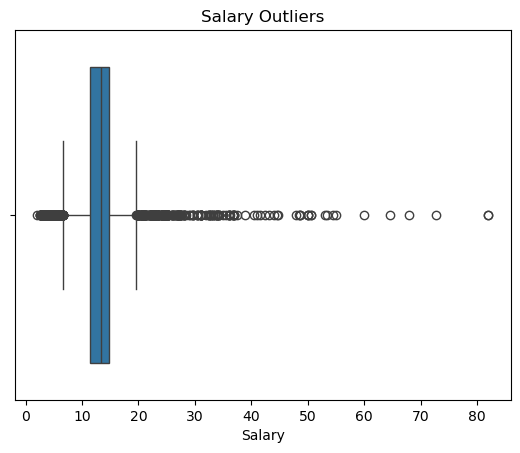

In [5]:
sns.boxplot(x=df["Salary"])
plt.title("Salary Outliers")
plt.show()

# Univariate Analysis

## 1.Role distribution

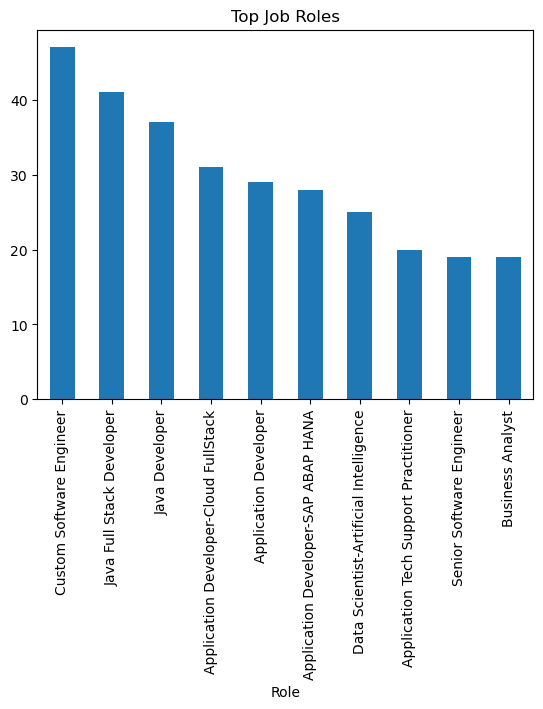

In [11]:
df["Role"].value_counts().head(10).plot(kind="bar")
plt.title("Top Job Roles")
plt.show()

## 2. Top Hiring Companies

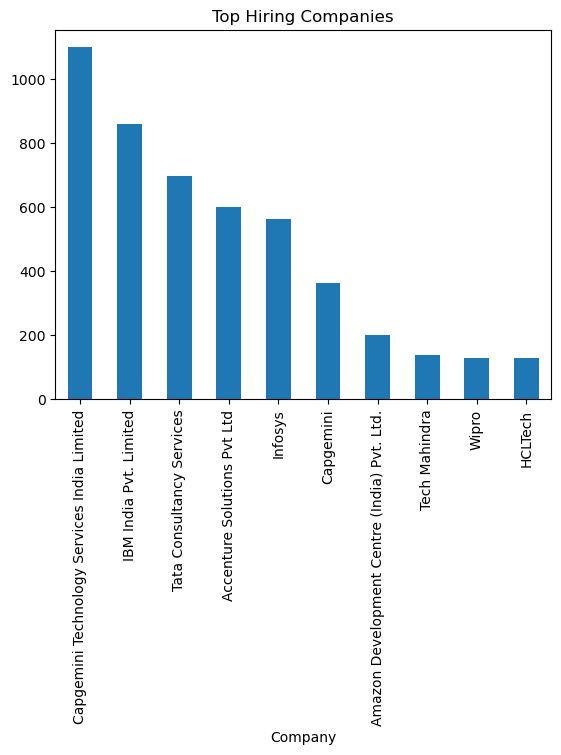

In [14]:
df["Company"].value_counts().head(10).plot(kind="bar")
plt.title("Top Hiring Companies")
plt.show()

## 3. Job Locations

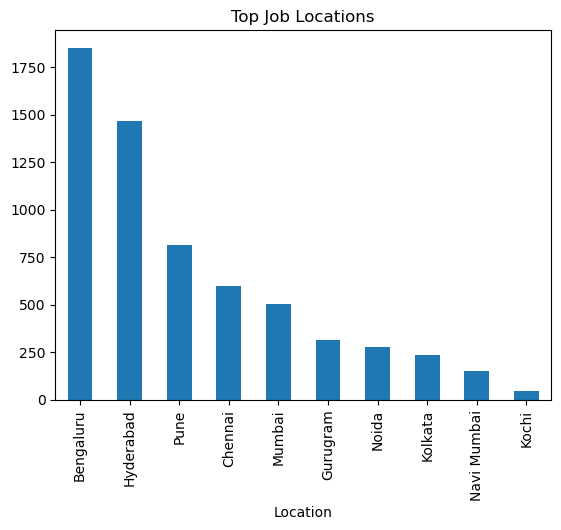

In [17]:
df["Location"].value_counts().head(10).plot(kind="bar")
plt.title("Top Job Locations")
plt.show()

## 4. Salary Distribution

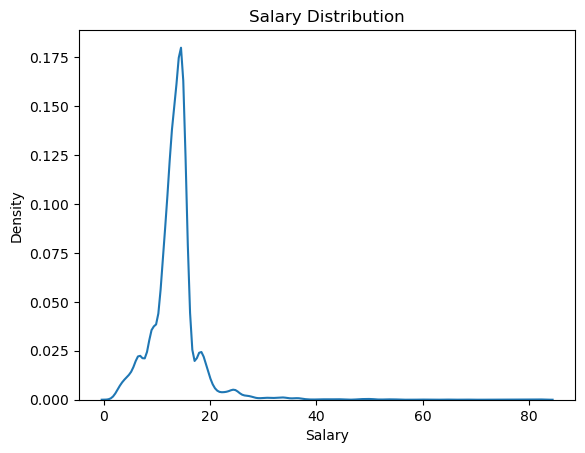

In [75]:
sns.kdeplot(df["Salary"])

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Density")

plt.show()

## 5. Experience Distribution

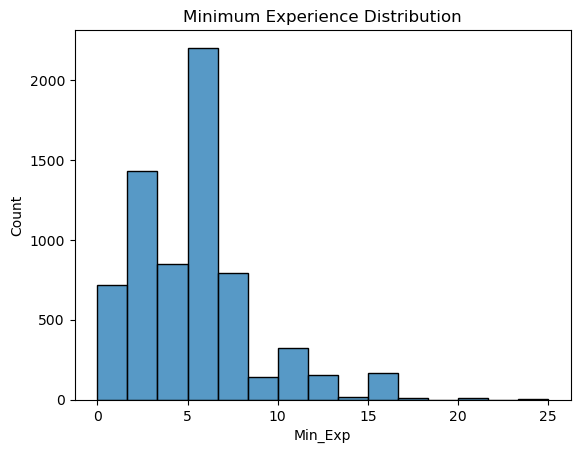

In [23]:
sns.histplot(df["Min_Exp"], bins=15)
plt.title("Minimum Experience Distribution")
plt.show()

## 6. Employment Type

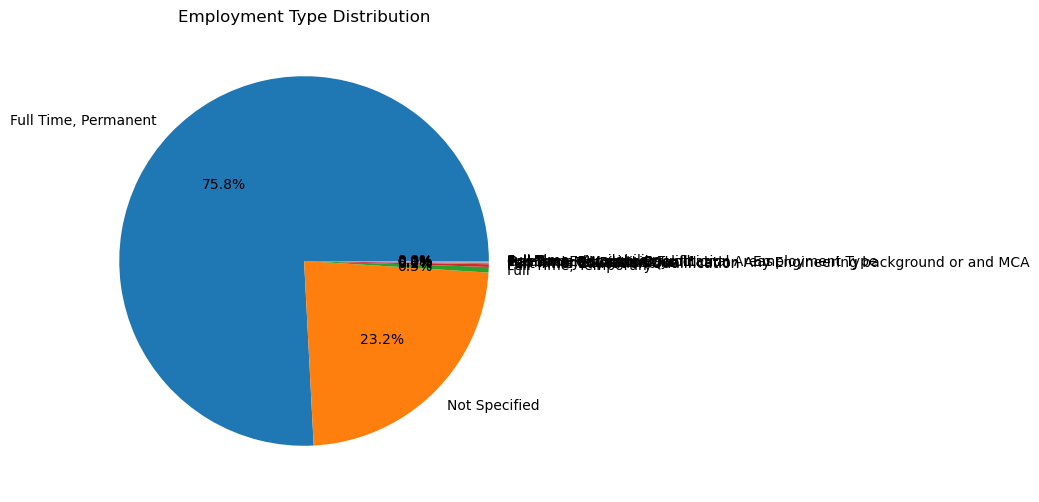

In [26]:
df["Emp_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Employment Type Distribution")
plt.ylabel("")
plt.show()

# Bivariate Analysis

## 1. Salary vs Experience

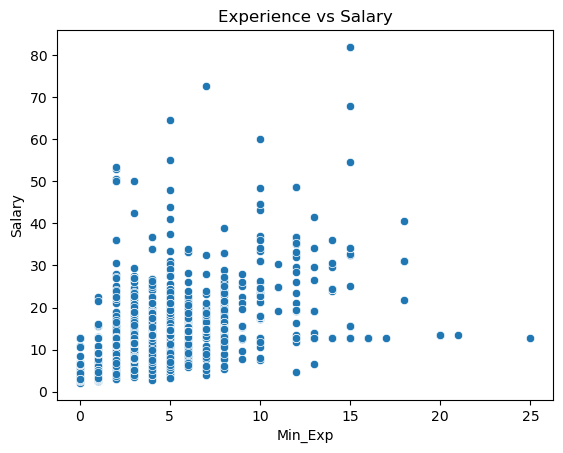

In [29]:
sns.scatterplot(x=df["Min_Exp"], y=df["Salary"])
plt.title("Experience vs Salary")
plt.show()

## Role vs Salary

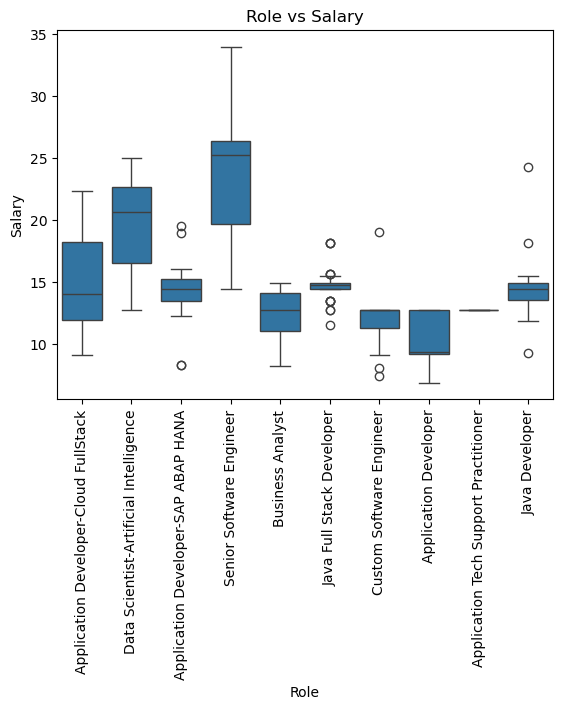

In [32]:
top_roles = df["Role"].value_counts().head(10).index

sns.boxplot(data=df[df["Role"].isin(top_roles)],
            x="Role", y="Salary")

plt.xticks(rotation=90)
plt.title("Role vs Salary")
plt.show()

## 3. Location vs Salary

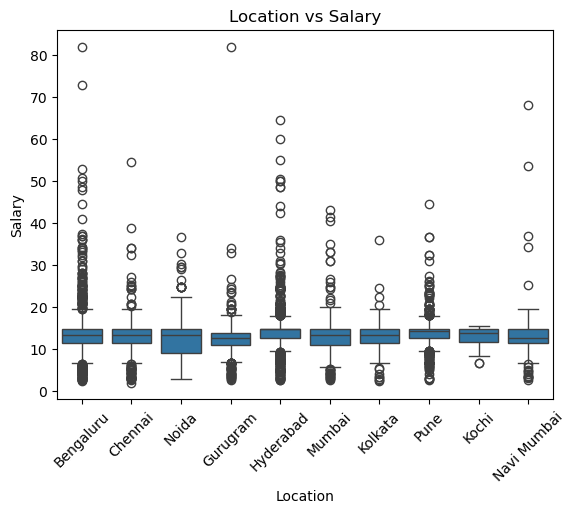

In [35]:
top_locations = df["Location"].value_counts().head(10).index

sns.boxplot(data=df[df["Location"].isin(top_locations)],
            x="Location", y="Salary")

plt.xticks(rotation=45)
plt.title("Location vs Salary")
plt.show()

## 4. Experience vs Role

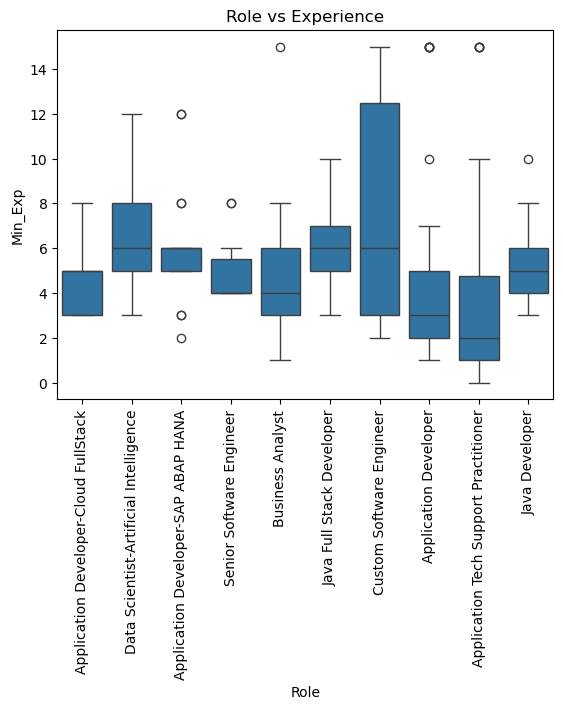

In [38]:
sns.boxplot(x="Role", y="Min_Exp", data=df[df["Role"].isin(top_roles)])

plt.xticks(rotation=90)
plt.title("Role vs Experience")
plt.show()

# Multivariate Analysis

## 1. Experience + Salary + Role

In [40]:
top_roles = df["Role"].value_counts().head(6).index

df_top_roles = df[df["Role"].isin(top_roles)]

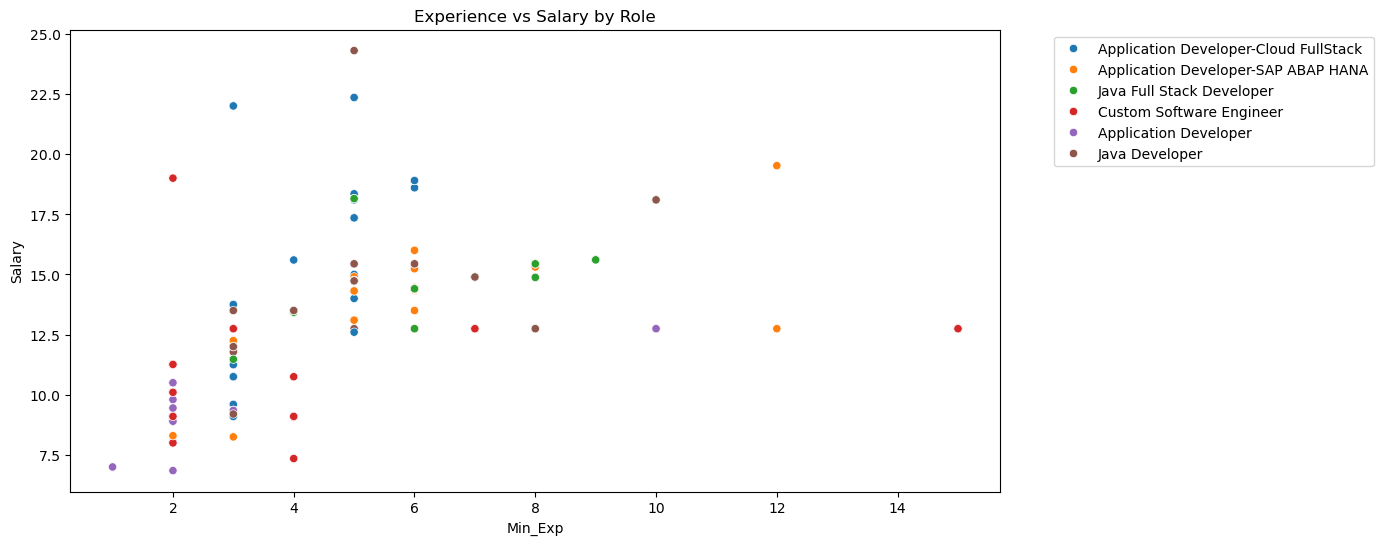

In [48]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_top_roles,
    x="Min_Exp",
    y="Salary",
    hue="Role"
)

plt.title("Experience vs Salary by Role")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### 2. Location + Role + Salary

In [52]:
top_roles = df["Role"].value_counts().head(5).index
top_locations = df["Location"].value_counts().head(5).index

In [54]:
df_filtered = df[
    (df["Role"].isin(top_roles)) &
    (df["Location"].isin(top_locations))
]

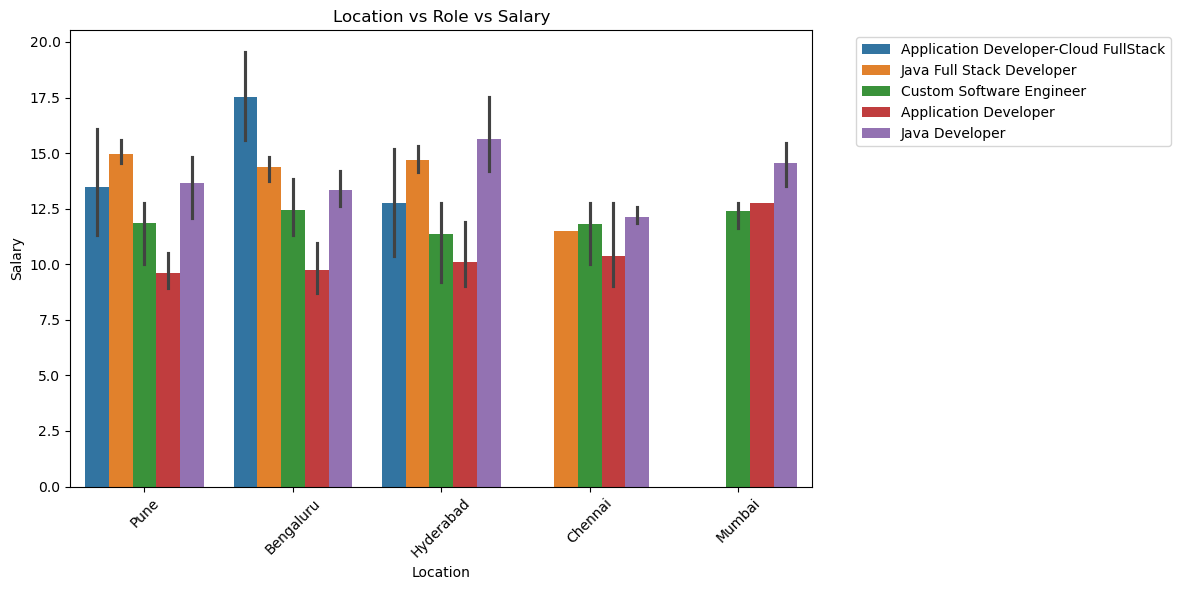

In [56]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_filtered,
    x="Location",
    y="Salary",
    hue="Role"
)

plt.xticks(rotation=45)
plt.title("Location vs Role vs Salary")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()

plt.show()

# Skills Analysis

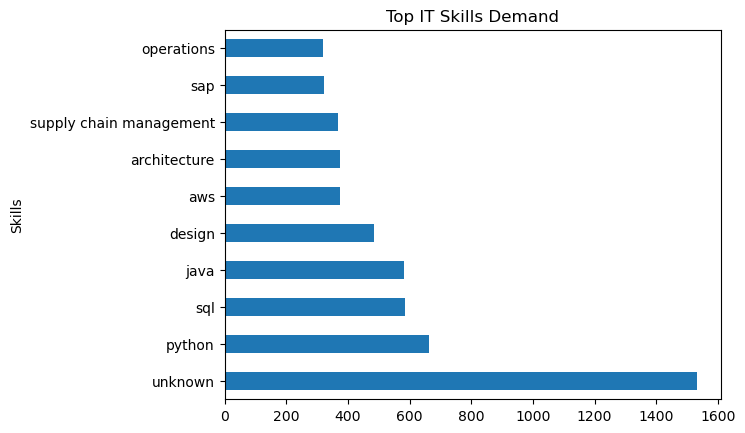

In [59]:
skills = df["Skills"].str.split(",").explode()

skills = skills.str.strip()

skills.value_counts().head(10).plot(kind="barh")

plt.title("Top IT Skills Demand")
plt.show()

## Pivot Tables
## 1. Average Salary by Role

In [99]:
pivot_role_salary = df.pivot_table(
    values="Salary",
    index="Role",
    aggfunc="mean"
)

pivot_role_salary.sort_values("Salary", ascending=False).head(10)

,Salary
Role,
S&C Global Network - AI - CMT Engineering -Associate Director,82.00
GN-IC-Comms and Media-Media- Senior Principal,68.00
"Sr Software Development Engineer, DSP Tech",64.55
"Senior Product Manager - Tech, Alexa Ads",60.00
Senior Product Manager - Tech,55.00
Principal Soft Engineer - Microsoft Dynamics 365 Finance & Operations,54.50
"Software Development Engineer II, TFS",53.50
"Software Development Engineer II, Aurora, Aurora Storage",53.00
"SDE II, Amazon Now",50.65


## Heatmap

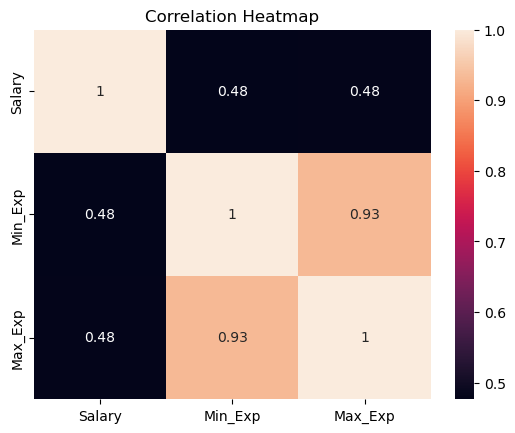

In [103]:
corr = df[["Salary","Min_Exp","Max_Exp"]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

## Pairplot

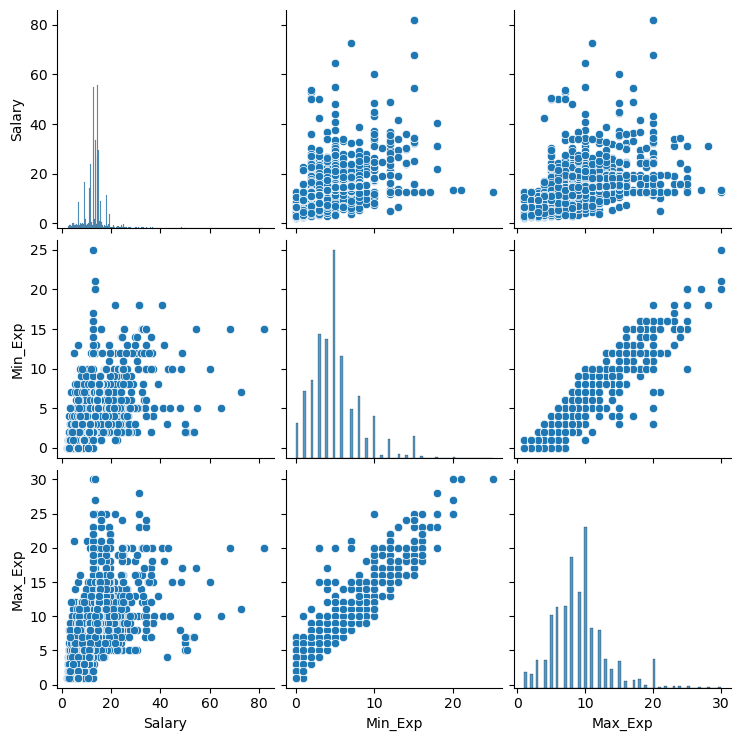

In [106]:
sns.pairplot(df[["Salary","Min_Exp","Max_Exp"]])
plt.show()

## Source Analysis

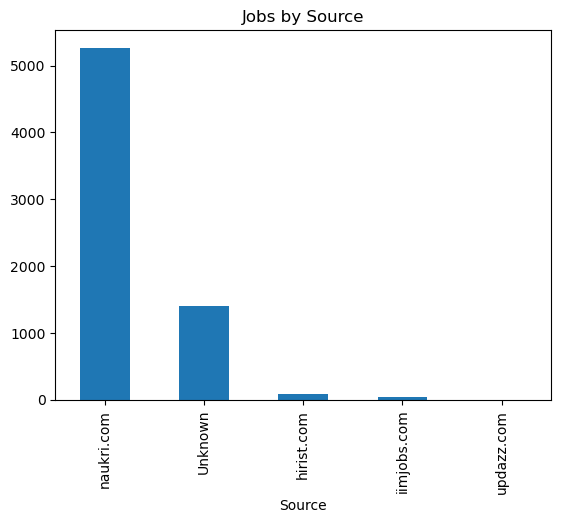

In [109]:
df["Source"].value_counts().plot(kind="bar")

plt.title("Jobs by Source")
plt.show()

## Jobs by Experience Level

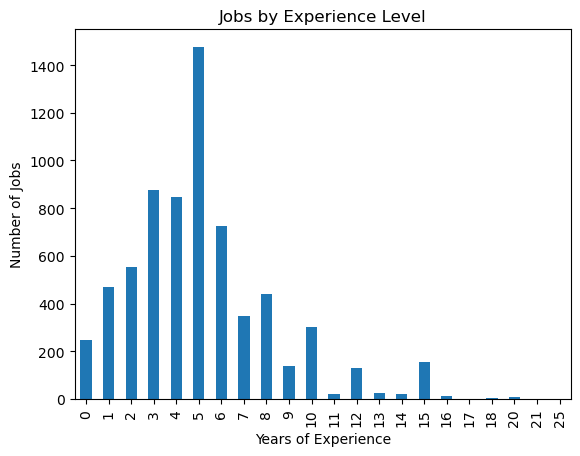

In [66]:
df["Min_Exp"].value_counts().sort_index().plot(kind="bar")
plt.title("Jobs by Experience Level")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Jobs")
plt.show()

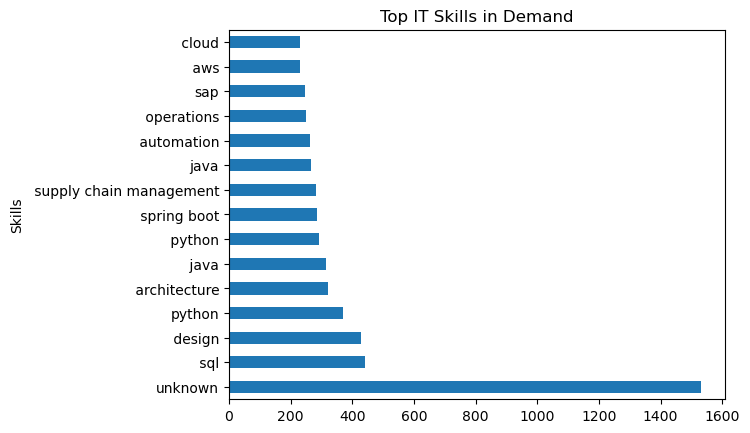

In [68]:
## Skills Frequency

skills = df["Skills"].str.split(",").explode()

skills.value_counts().head(15).plot(kind="barh")
plt.title("Top IT Skills in Demand")
plt.show()

## Salary vs Experience Trend

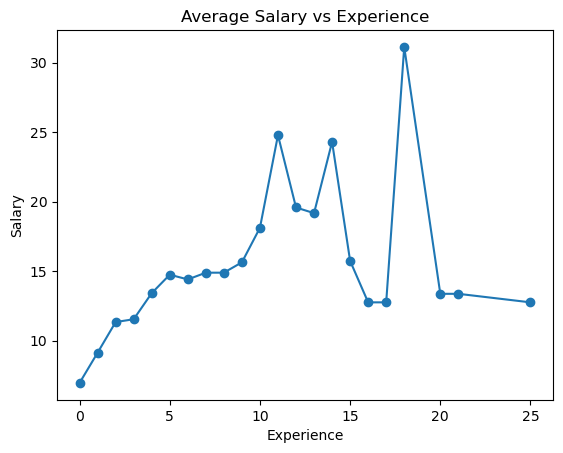

In [71]:
salary_exp = df.groupby("Min_Exp")["Salary"].mean()

salary_exp.plot(kind="line", marker="o")
plt.title("Average Salary vs Experience")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()